# Assignment 3: Linear Models


**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?



### Answers

1. A model is **linear** when it is linear in its **unknown coefficients/parameters**. In other words, the prediction is built by adding together an intercept and coefficients times variables. The variables themselves can be transformed, but the coefficients still enter in a straight-line way.

2. With an intercept in the model, the coefficient on a dummy variable is interpreted **relative to the omitted baseline category**. The intercept is the predicted outcome for the baseline group, and the dummy coefficient tells us how much higher or lower that group is compared with the baseline.

3. Linear regression can be used for classification as a rough approximation, but it is usually not the right tool. Its predictions are not restricted to lie between 0 and 1, so they are not well-behaved probabilities. Logistic regression is usually better because it models probabilities directly.

4. Signs of overfitting include very low training error, noticeably worse test error, unstable coefficients, and a model that seems to chase noise rather than the main pattern in the data.

5. Multicollinearity means one regressor can be explained well by other regressors, so it is hard to isolate its unique effect. In a two-stage least squares style way of thinking, if you first regress one variable on the others, the fitted values can be very close to the original variable. That means there is very little independent variation left, so the second-stage coefficient is unstable and its standard error becomes large.

6. Nonlinear relationships can be added by including transformed variables such as $x^2$, $x^3$, $\log(x)$, or interaction terms. You can also use splines or other flexible basis expansions while still estimating the model with linear regression.

7. The slope coefficient gives the expected change in $y$ from a one-unit increase in $x$, **holding the other included variables fixed**.

8. A train/test split uses one split of the sample into a training set and a testing set. It is simple, but the estimate can depend a lot on the particular split. $k$-fold cross validation repeatedly rotates which observations are used for validation, so it uses the data more efficiently and usually gives a more stable estimate of out-of-sample performance.

9. The $k$ in $k$-fold cross validation is usually chosen by convention and computational convenience. Common choices are **5-fold** or **10-fold** cross validation because they balance computation time with a reliable estimate of predictive performance.


In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')



**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.


In [2]:

# Q2.1 Load and clean data
q2 = pd.read_csv('./data/Q1_clean.csv')
q2 = q2.rename(columns={'Review Scores Rating': 'Review_Scores_Rating'})

print(q2.head())
print(q2.shape)


   Price  Review_Scores_Rating Neighbourhood  Property Type        Room Type
0    549                96.000      Manhattan     Apartment     Private room
1    149               100.000       Brooklyn     Apartment  Entire home/apt
2    250               100.000      Manhattan     Apartment  Entire home/apt
3     90                94.000       Brooklyn     Apartment     Private room
4    270                90.000      Manhattan     Apartment  Entire home/apt
(22153, 5)


In [5]:

# Q2.1 Average prices and ratings by neighbourhood
q2_means = q2.groupby('Neighbourhood ')[['Price', 'Review_Scores_Rating']].mean().sort_values('Price', ascending=False)
print(q2_means)
print('Most expensive borough on average:', q2_means.index[0])


                 Price  Review_Scores_Rating
Neighbourhood                               
Manhattan      183.664                91.801
Staten Island  146.167                90.844
Brooklyn       127.747                92.363
Queens          96.857                91.549
Bronx           75.276                91.654
Most expensive borough on average: Manhattan


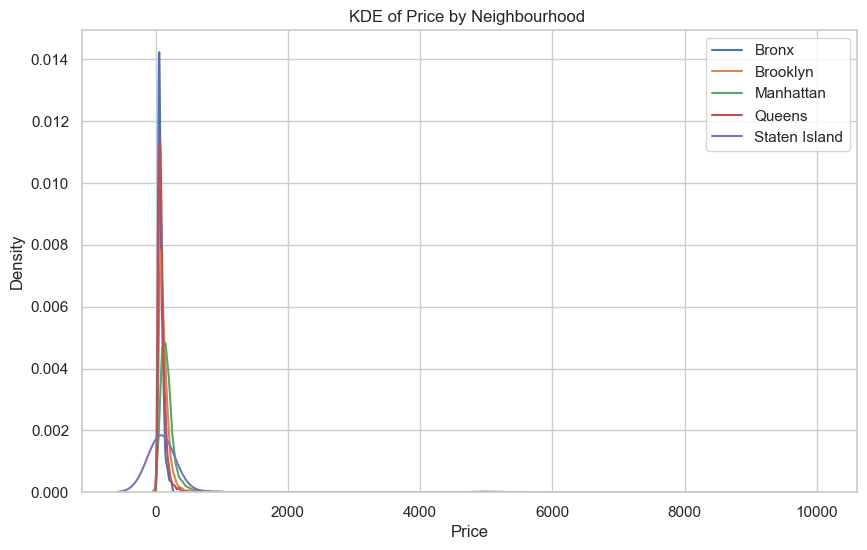

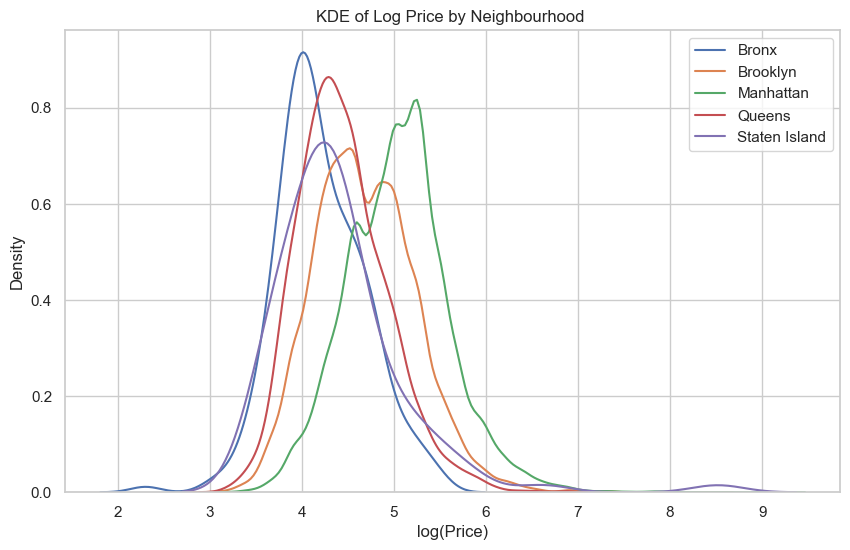

In [7]:

# Q2.1 KDE plots for price and log price by neighbourhood
q2['log_price'] = np.log(q2['Price'])

plt.figure(figsize=(10, 6))
for name, grp in q2.groupby('Neighbourhood '):
    sns.kdeplot(grp['Price'], label=name, fill=False)
plt.title('KDE of Price by Neighbourhood ')
plt.xlabel('Price')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
for name, grp in q2.groupby('Neighbourhood '):
    sns.kdeplot(grp['log_price'], label=name, fill=False)
plt.title('KDE of Log Price by Neighbourhood ')
plt.xlabel('log(Price)')
plt.legend()
plt.show()


In [10]:
q2.columns = q2.columns.str.strip()
m_q2_neigh = smf.ols('Price ~ C(Neighbourhood)', data=q2).fit()
print(m_q2_neigh.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        22:45:47   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc


**Q2.2 interpretation:** With an intercept in the model, the omitted neighbourhood is the baseline group. The intercept is the average price in that baseline borough, and each neighbourhood coefficient is the difference between that borough's mean price and the baseline mean. If you add the intercept to a borough's dummy coefficient, you recover that borough's conditional group mean.


In [12]:

# Q2.3 Price on review score
m_q2_score = smf.ols('Price ~ Review_Scores_Rating', data=q2).fit()
print(m_q2_score.summary())
print('Slope on Review_Scores_Rating:', m_q2_score.params['Review_Scores_Rating'])


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        22:45:53   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               60.8784 


**Q2.3 interpretation:** The slope on `Review_Scores_Rating` gives the predicted change in nightly price for a one-point increase in average review score.


In [13]:

# Q2.4 Price on neighbourhood and review score
m_q2_both = smf.ols('Price ~ C(Neighbourhood) + Review_Scores_Rating', data=q2).fit()
print(m_q2_both.summary())

compare_q2 = pd.DataFrame({
    'score_only': m_q2_score.params,
    'neighbourhood_plus_score': m_q2_both.params
})
print(compare_q2)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Thu, 19 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        22:45:58   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc


**Q2.4 interpretation:** Compare the coefficient on `Review_Scores_Rating` here to the previous regression. If the coefficient changes, that means neighbourhood and review scores are correlated, so part of the rating effect in the simpler model was also picking up location differences.


In [15]:

# Q2.5 Separate review-score slopes by neighbourhood
m_q2_interact = smf.ols('Price ~ C(Neighbourhood) * Review_Scores_Rating', data=q2).fit()
print(m_q2_interact.summary())

# Compute neighbourhood-specific slopes
base_name = 'Review_Scores_Rating'
base_slope = m_q2_interact.params[base_name]
print('Baseline slope:', base_slope)
print('Neighbourhood-specific review-score slopes:')
for level in sorted(q2['Neighbourhood'].unique()):
    term = f'C(Neighbourhood)[T.{level}]:Review_Scores_Rating'
    slope = base_slope + m_q2_interact.params.get(term, 0)
    print(level, ':', slope)


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Thu, 19 Mar 2026   Prob (F-statistic):               0.00
Time:                        22:46:06   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                             coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------


**Q2.5 interpretation:** If the neighbourhood-specific slopes are close to one another, the relationship between ratings and price is fairly similar across boroughs. If they differ a lot, then the value of an extra review point depends strongly on neighbourhood.


In [16]:

# Q2.6 Cross validation for the main linear models
q2_dummies = pd.get_dummies(q2[['Neighbourhood']], drop_first=True)
X_q2_model3 = q2[['Review_Scores_Rating']]
X_q2_model4 = pd.concat([q2[['Review_Scores_Rating']], q2_dummies], axis=1)
X_q2_model5 = X_q2_model4.copy()
for col in q2_dummies.columns:
    X_q2_model5[f'{col}_x_score'] = X_q2_model5[col] * q2['Review_Scores_Rating']

y_q2 = q2['Price']
cv10 = KFold(n_splits=10, shuffle=True, random_state=42)

cv_q2 = pd.DataFrame({
    'Model': ['Score only', 'Neighbourhood + score', 'Neighbourhood-specific slopes'],
    'CV_RMSE': [
        np.sqrt(-cross_val_score(LinearRegression(), X_q2_model3, y_q2, cv=cv10, scoring='neg_mean_squared_error')).mean(),
        np.sqrt(-cross_val_score(LinearRegression(), X_q2_model4, y_q2, cv=cv10, scoring='neg_mean_squared_error')).mean(),
        np.sqrt(-cross_val_score(LinearRegression(), X_q2_model5, y_q2, cv=cv10, scoring='neg_mean_squared_error')).mean()
    ]
})
print(cv_q2.sort_values('CV_RMSE'))


                           Model  CV_RMSE
1          Neighbourhood + score  139.010
2  Neighbourhood-specific slopes  139.999
0                     Score only  142.759


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [18]:

# Q3.1 Load and summarize car data
cars = pd.read_csv('./data/cars_hw.csv')
print(cars.head())
print(cars.shape)
print('Price summary:')
print(cars['Price'].describe())


   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manual   

    Price  
0  657000  
1  682000  
2  793000  
3  414000  
4  515000  
(976, 12)
Price summary:
count  

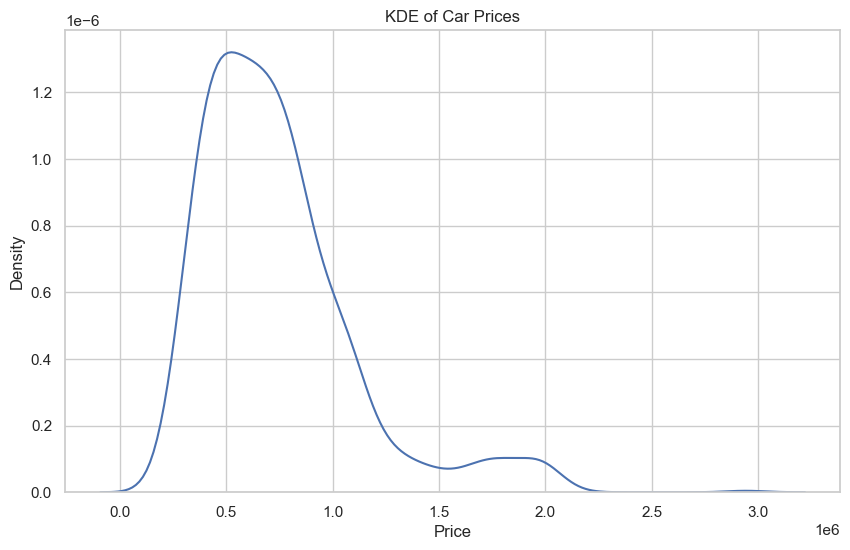

            count          mean         std         min         25%  \
Body_Type                                                             
crossover  21.000   705,095.238  72,849.780 608,000.000 638,000.000   
hatchback 484.000   533,977.273 173,086.730 188,000.000 401,750.000   
muv        38.000   626,421.053 184,093.489 328,000.000 489,750.000   
sedan     227.000   809,784.141 286,736.770 368,000.000 598,000.000   
suv       206.000 1,176,495.146 417,479.028 559,000.000 860,000.000   

                    50%           75%           max  
Body_Type                                            
crossover   706,000.000   749,000.000   883,000.000  
hatchback   509,000.000   661,000.000 1,107,000.000  
muv         621,500.000   738,500.000 1,091,000.000  
sedan       772,000.000   968,500.000 2,941,000.000  
suv       1,065,000.000 1,491,250.000 2,100,000.000  


In [19]:

# Q3.1 KDE for price and grouped summaries by body type
plt.figure(figsize=(10, 6))
sns.kdeplot(cars['Price'], fill=False)
plt.title('KDE of Car Prices')
plt.xlabel('Price')
plt.show()

cars_group = cars.groupby('Body_Type')['Price'].describe()
print(cars_group)


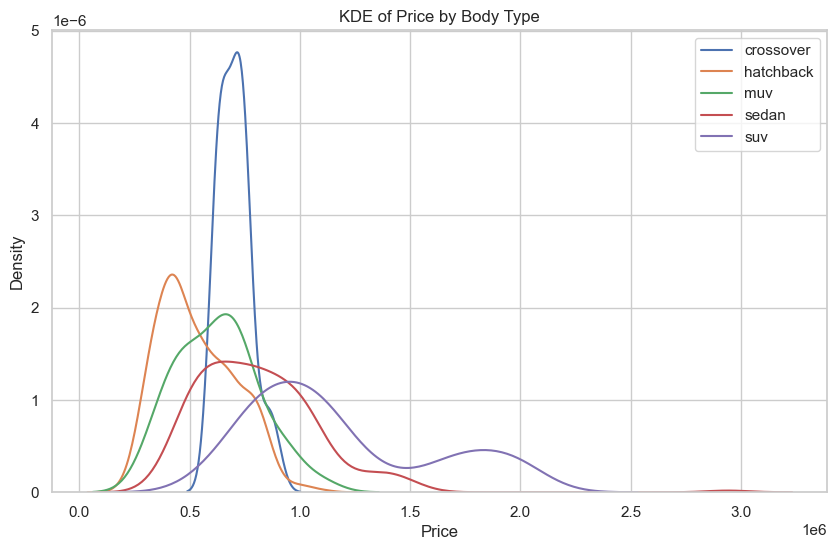

In [20]:

plt.figure(figsize=(10, 6))
for name, grp in cars.groupby('Body_Type'):
    sns.kdeplot(grp['Price'], label=name, fill=False)
plt.title('KDE of Price by Body Type')
plt.xlabel('Price')
plt.legend()
plt.show()



**Q3.1 interpretation:** Use the grouped means and standard deviations above to identify which body types are most expensive on average and which have the greatest price dispersion.


In [22]:

# Q3.2 Linear price-seat regression
m_cars_seat_linear = smf.ols('Price ~ Seating_Capacity', data=cars).fit()
print(m_cars_seat_linear.summary())
print('Slope on Seating_Capacity:', m_cars_seat_linear.params['Seating_Capacity'])


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0245
Time:                        22:46:21   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  


**Q3.2 interpretation:** The slope on `Seating_Capacity` is the predicted change in price from adding one seat, on average.


In [23]:

# Q3.2 Treat seating capacity as categorical
m_cars_seat_cat = smf.ols('Price ~ C(Seating_Capacity)', data=cars).fit()
print(m_cars_seat_cat.summary())


                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000267
Time:                        22:46:24   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               


**Q3.2 comparison:** Compare the seat-category coefficients to see whether prices rise in an approximately straight-line way as seating capacity increases. If the category effects jump around a lot, the relationship is not very linear.


In [25]:

# Q3.3 Age variable and 10-fold CV for polynomial degree
cars['Age'] = cars['Make_Year'].max() - cars['Make_Year']
X_age = cars[['Age']]
y_age = cars['Price']

degrees = list(range(1, 11))
cv_rows = []

for d in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('lr', LinearRegression())
    ])
    rmse = np.sqrt(-cross_val_score(pipe, X_age, y_age, cv=cv10, scoring='neg_mean_squared_error')).mean()
    cv_rows.append((d, rmse))

cv_cars = pd.DataFrame(cv_rows, columns=['degree', 'CV_RMSE'])
print(cv_cars)

best_degree = int(cv_cars.loc[cv_cars['CV_RMSE'].idxmin(), 'degree'])
print('Optimal degree:', best_degree)


   degree     CV_RMSE
0       1 310,765.361
1       2 310,779.296
2       3 309,697.345
3       4 308,871.568
4       5 307,368.982
5       6 307,522.524
6       7 306,433.419
7       8 304,974.926
8       9 304,139.384
9      10 304,190.871
Optimal degree: 9


/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


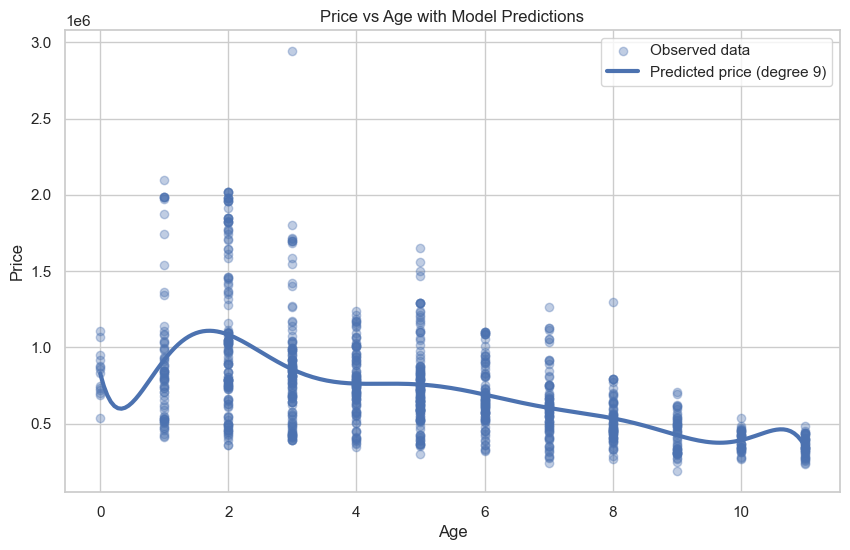

In [26]:

# Q3.4 Fit best polynomial model and plot predictions against Age
best_pipe = Pipeline([
    ('poly', PolynomialFeatures(degree=best_degree, include_bias=False)),
    ('lr', LinearRegression())
])
best_pipe.fit(X_age, y_age)

age_grid = pd.DataFrame({'Age': np.linspace(cars['Age'].min(), cars['Age'].max(), 200)})
pred_grid = best_pipe.predict(age_grid)

plt.figure(figsize=(10, 6))
plt.scatter(cars['Age'], cars['Price'], alpha=0.35, label='Observed data')
plt.plot(age_grid['Age'], pred_grid, linewidth=3, label=f'Predicted price (degree {best_degree})')
plt.title('Price vs Age with Model Predictions')
plt.xlabel('Age')
plt.ylabel('Price')
plt.legend()
plt.show()



**Q3.4 interpretation:** Compare the smooth prediction curve to the cloud of points. If the curve follows the main downward price pattern without chasing small fluctuations, the model is capturing the broad relationship reasonably well.



**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [27]:

# Q4 Load data
heart = pd.read_csv('./data/heart_hw.csv')
print(heart.head())
print(heart.shape)


   Unnamed: 0  age transplant  y
0           1   53    control  0
1           2   43    control  0
2           3   52    control  0
3           4   52    control  0
4           5   54    control  0
(103, 4)


In [28]:

# Q4.1 Survival rates by treatment status and ATE
heart_rates = heart.groupby('transplant')['y'].mean()
control_rate = heart_rates['control']
treatment_rate = heart_rates['treatment']
ate = treatment_rate - control_rate

print('Control survival rate:', control_rate)
print('Treatment survival rate:', treatment_rate)
print('ATE (treatment - control):', ate)


Control survival rate: 0.11764705882352941
Treatment survival rate: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


In [29]:

# Q4.2 Linear probability model with transplant only
m_heart1 = smf.ols('y ~ C(transplant)', data=heart).fit()
print(m_heart1.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0133
Time:                        22:46:33   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           


**Q4.2 interpretation:** With an intercept in the model, the intercept is the average survival rate for the baseline group and the transplant coefficient is the difference in survival between treatment and control. Those should match the numbers from part 1.


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000357
Time:                        22:46:34   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

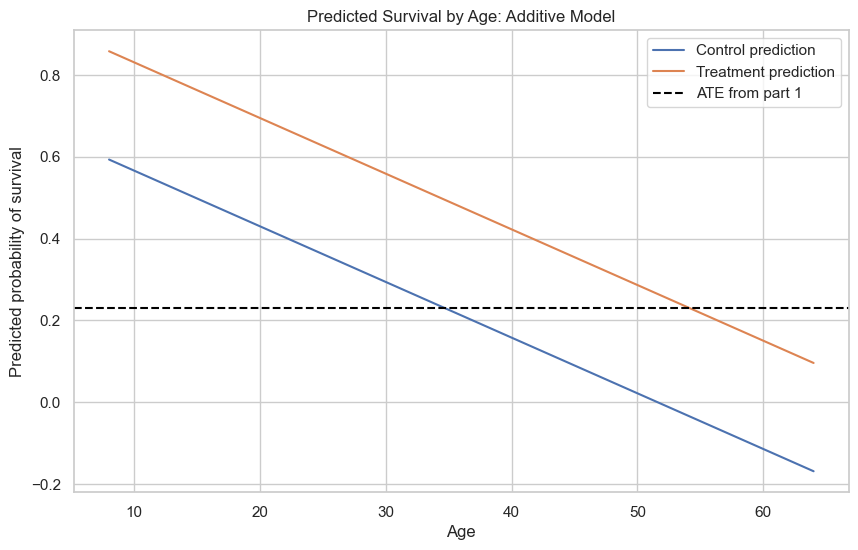

In [30]:

# Q4.3 Add age
m_heart2 = smf.ols('y ~ C(transplant) + age', data=heart).fit()
print(m_heart2.summary())

age_grid = pd.DataFrame({
    'age': np.linspace(heart['age'].min(), heart['age'].max(), 200)
})
control_pred = age_grid.copy()
control_pred['transplant'] = 'control'
treat_pred = age_grid.copy()
treat_pred['transplant'] = 'treatment'

control_y = m_heart2.predict(control_pred)
treat_y = m_heart2.predict(treat_pred)

plt.figure(figsize=(10, 6))
plt.plot(age_grid['age'], control_y, label='Control prediction')
plt.plot(age_grid['age'], treat_y, label='Treatment prediction')
plt.axhline(ate, linestyle='--', color='black', label='ATE from part 1')
plt.title('Predicted Survival by Age: Additive Model')
plt.xlabel('Age')
plt.ylabel('Predicted probability of survival')
plt.legend()
plt.show()



**Q4.3 interpretation:** In this additive model, the transplant effect is constant across ages, so the vertical distance between the treatment and control lines does not change with age. The intercept is the predicted survival for the baseline transplant group at age 0, and the age slope is the change in predicted survival from one more year of age, holding transplant status fixed.


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           0.000310
Time:                        22:46:35   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

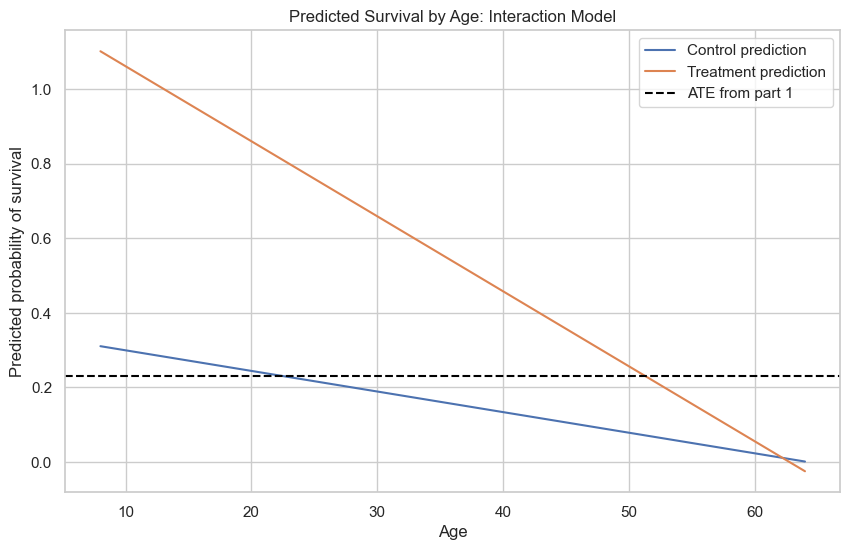

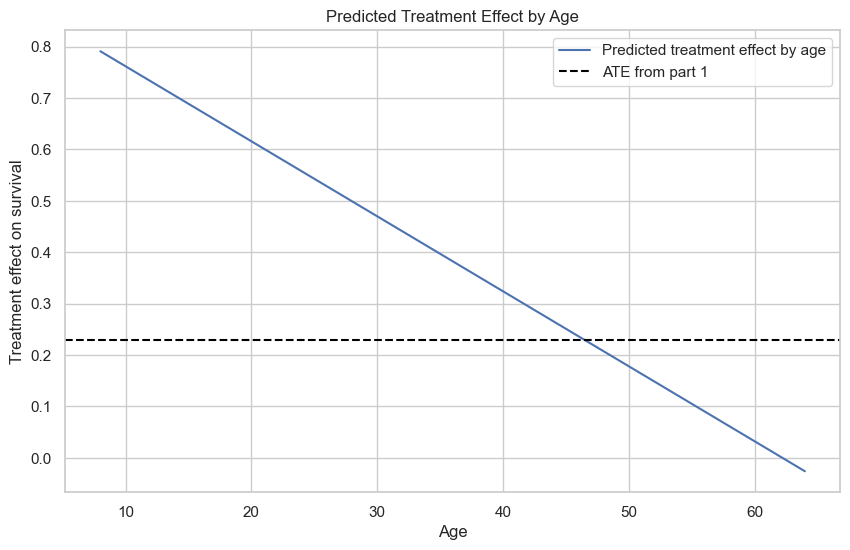

In [31]:

# Q4.4 Add interaction between transplant and age
m_heart3 = smf.ols('y ~ C(transplant) * age', data=heart).fit()
print(m_heart3.summary())

control_y_int = m_heart3.predict(control_pred)
treat_y_int = m_heart3.predict(treat_pred)

effect_by_age = treat_y_int - control_y_int

plt.figure(figsize=(10, 6))
plt.plot(age_grid['age'], control_y_int, label='Control prediction')
plt.plot(age_grid['age'], treat_y_int, label='Treatment prediction')
plt.axhline(ate, linestyle='--', color='black', label='ATE from part 1')
plt.title('Predicted Survival by Age: Interaction Model')
plt.xlabel('Age')
plt.ylabel('Predicted probability of survival')
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(age_grid['age'], effect_by_age, label='Predicted treatment effect by age')
plt.axhline(ate, linestyle='--', color='black', label='ATE from part 1')
plt.title('Predicted Treatment Effect by Age')
plt.xlabel('Age')
plt.ylabel('Treatment effect on survival')
plt.legend()
plt.show()



**Q4.4 interpretation:** Once the interaction is added, the effect of transplant is allowed to vary with age. If the treatment-effect line slopes upward or downward, that means the transplant benefit is different for younger and older patients.


In [32]:

# Q4.5 10-fold CV for predictive accuracy
heart_X1 = pd.get_dummies(heart[['transplant']], drop_first=True)
heart_X2 = pd.concat([heart[['age']], heart_X1], axis=1)
heart_X3 = heart_X2.copy()
heart_X3['transplant_x_age'] = heart_X3.iloc[:, 1] * heart_X3['age']
heart_y = heart['y']

cv_heart = pd.DataFrame({
    'Model': ['Transplant only', 'Transplant + age', 'Transplant + age + interaction'],
    'CV_RMSE': [
        np.sqrt(-cross_val_score(LinearRegression(), heart_X1, heart_y, cv=cv10, scoring='neg_mean_squared_error')).mean(),
        np.sqrt(-cross_val_score(LinearRegression(), heart_X2, heart_y, cv=cv10, scoring='neg_mean_squared_error')).mean(),
        np.sqrt(-cross_val_score(LinearRegression(), heart_X3, heart_y, cv=cv10, scoring='neg_mean_squared_error')).mean()
    ]
})
print(cv_heart.sort_values('CV_RMSE'))


                            Model  CV_RMSE
2  Transplant + age + interaction    0.413
1                Transplant + age    0.417
0                 Transplant only    0.437



**Q4.6 concerns about model construction and deployment:**

- This is observational data, so treatment assignment is not random. Sicker or healthier patients may be more likely to receive transplants, which can bias the estimated treatment effect.
- A linear probability model can predict values below 0 or above 1, which is not ideal for probabilities.
- Important confounders may be missing, such as illness severity, comorbidities, income, access to care, or hospital quality.
- A model used for prioritization can embed unfair historical patterns and amplify unequal access to treatment.
- Even a good predictive model is not automatically a good decision rule. Clinical judgment, ethics, and fairness constraints still matter.
